This tutorial demonstrates how to account for the influence of noise when measuring the relationship between variables. It shows that noise can decrease the observed correlation between two truly related variables. To address this, the tutorial utilizes a technique called split-half reliability to estimate the consistency of the measurements. This reliability estimate is then used to correct the observed correlation, providing a more accurate representation of the true relationship between the variables, even in the presence of noise. Finally, the tutorial highlights how increasing the number of measurements improves the reliability and thus the accuracy of the corrected correlation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Lets define two variables 'a' and 'b' that are perfectly correlated with each other
a = np.random.randn(100, 1) # This variable will be only defined once
b = 0.3 * a # 'b' is fully correlated with 'a'

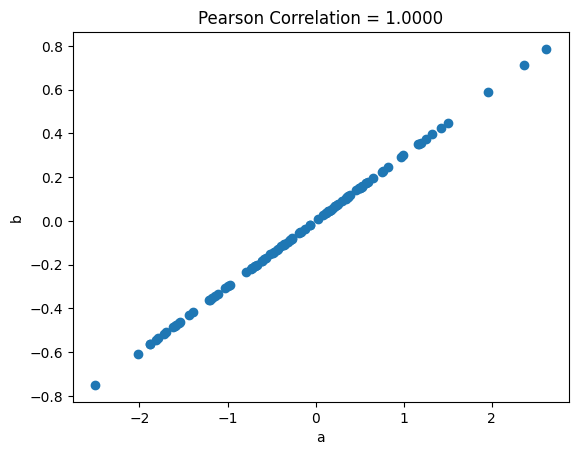

In [ ]:
# Let's plot this two variables against each other

# Scatter plot
plt.scatter(a, b, marker='o')
# Set labels and title
plt.xlabel('a')
plt.ylabel('b')
correlation = np.corrcoef(a.squeeze(), b.squeeze())[0, 1]
plt.title(f"Pearson Correlation = {correlation:.4f}")
plt.show()

In [ ]:
# lets assume we run 50 trials to estimate the variable 'b' that is being measured with a noisy device (Device A)

nrTrials = 50

# Initialize the variable
b_noisy = np.empty((100, nrTrials))
b_noisy[:] = np.nan  # fill the entire array with NaNs

for i in range(nrTrials):
    # In each trial we get the true 'b' plus some noise (based on the device noise)
    b_noisy[:, i] = b.squeeze() + 0.3 * np.random.randn(100)

avg_b_noisy = np.mean(b_noisy, axis=1) # our best estimate of the true 'b' based on the noisy measurements


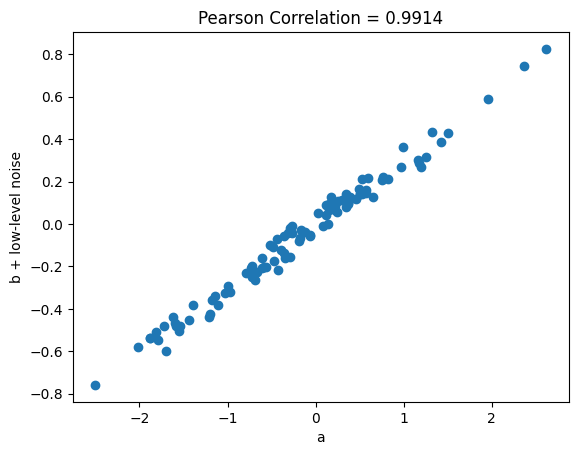

In [ ]:
# Now let's replot this two variables against each other ('a' versus 'b' when estimated under noise)
# Scatter plot
plt.scatter(a, avg_b_noisy, marker='o')

# Set labels and title
plt.xlabel('a')
plt.ylabel('b + low-level noise')
correlation = np.corrcoef(a.squeeze(), avg_b_noisy)[0, 1]
plt.title(f"Pearson Correlation = {correlation:.4f}")

plt.show()

# Note that the correlation has dropped from 1 to a lower value because our measurement was noisy

In [ ]:
# Add more noise (that is let's say we are measuring 'b' with an even noisier device: (Device B))

for i in range(nrTrials):
    # In each trial we get the real 'b' plus some noise
    b_noisy[:, i] = b.squeeze() + 1.3 * np.random.randn(100) # the amount of noise is proportional to the stdev of this gaussian variable

avg_b_noisy = np.mean(b_noisy, axis=1)


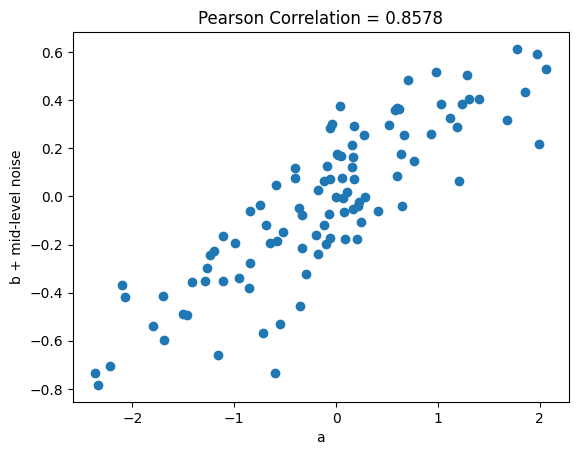

In [ ]:
# Now let's replot this two variables against each other ('a' versus 'b' when estimated under more noise)

# Scatter plot
plt.scatter(a, avg_b_noisy, marker='o')

# Set labels and title
plt.xlabel('a')
plt.ylabel('b + mid-level noise')
correlation = np.corrcoef(a.squeeze(), avg_b_noisy)[0, 1]
plt.title(f"Pearson Correlation = {correlation:.4f}")

plt.show()

# Note that the correlation has dropped to a lower value because our measurement was noisier

In [ ]:
# Add more noise (even worse device noise): (Device C)

for i in range(nrTrials):
    # In each trial we get the real 'b' plus some noise
    b_noisy[:, i] = b.squeeze() + 1.8 * np.random.randn(100)

avg_b_noisy = np.mean(b_noisy, axis=1)


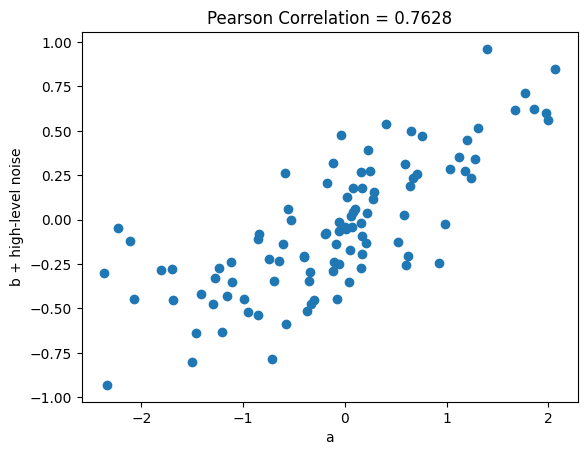

In [ ]:
# Scatter plot
plt.scatter(a, avg_b_noisy, marker='o')

# Set labels and title
plt.xlabel('a')
plt.ylabel('b + high-level noise')
correlation = np.corrcoef(a.squeeze(), avg_b_noisy)[0, 1]
plt.title(f"Pearson Correlation = {correlation:.4f}")

plt.show()

# Note that the correlation has dropped to a lower value because our measurement was even noisier

In [ ]:
# Let's make a new variable that is not fully correlated with 'a'

c = 0.3 * a + 0.15*np.random.randn(100, 1) # Note: This is not a noisy measurement. This is the ground truth of 'c'


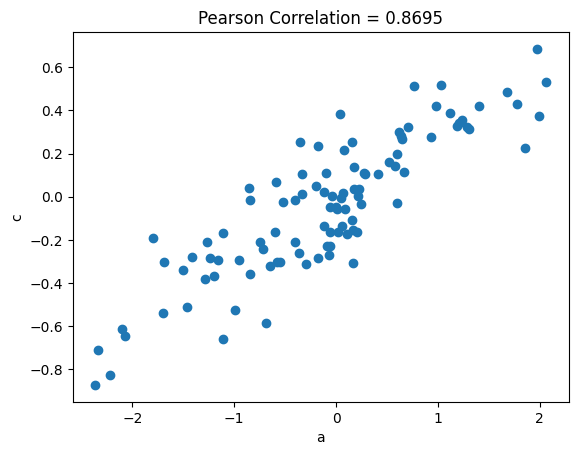

In [ ]:
# Scatter plot
plt.scatter(a, c, marker='o')

# Set labels and title
plt.xlabel('a')
plt.ylabel('c')
correlation = np.corrcoef(a.squeeze(), c.squeeze())[0, 1]
plt.title(f"Pearson Correlation = {correlation:.4f}")

plt.show()

# Note: Compare to the true 'b' , when correlation was 1 with 'a', here it is less than 1

In [ ]:
## lets assume we run 50 trials to estimate the variable 'c' that is being measured with a noisy device (Device A)

nrTrials = 50

# Initialize the variable
c_noisy = np.empty((100, nrTrials))
c_noisy[:] = np.nan  # fill the entire array with NaNs

for i in range(nrTrials):
    # In each trial we get the real 'b' plus some noise
    c_noisy[:, i] = c.squeeze() + 0.3 * np.random.randn(100)

avg_c_noisy = np.mean(c_noisy, axis=1)

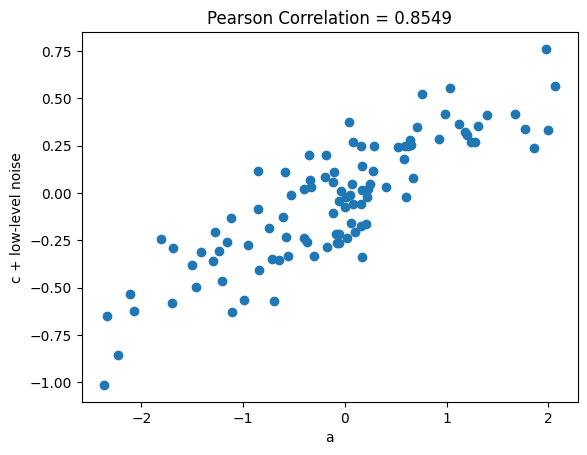

In [ ]:
# Scatter plot
plt.scatter(a, avg_c_noisy, marker='o')

# Set labels and title
plt.xlabel('a')
plt.ylabel('c + low-level noise')
correlation = np.corrcoef(a.squeeze(), avg_c_noisy)[0, 1]
plt.title(f"Pearson Correlation = {correlation:.4f}")

plt.show()

# Note: Now if measured 'b' with Device-C and 'c' with Device-C , we would infer than 'c' and 'a' are more correlated
# than 'a' and 'b' based on the R values

In [ ]:
print(f"size of a = {a.shape}")
print(f"size of b_noisy = {b_noisy.shape}")
print(f"size of c_noisy = {c_noisy.shape}")

size of a = (100, 1)
size of b_noisy = (100, 50)
size of c_noisy = (100, 50)


In [ ]:
# Estimate the reliability of the variables 'c' and 'b' that was repeatedly measured with the devices
nrBS = 1000
nrTrials = 50

sh_reliability_b = np.empty(nrBS)
sh_reliability_b[:] = np.nan

sh_reliability_c = np.empty(nrBS)
sh_reliability_c[:] = np.nan

for i in range(nrBS):
    l1 = np.random.choice(nrTrials, int(nrTrials/2), replace=False)
    l2 = np.setdiff1d(np.arange(nrTrials), l1)

    b_sh1 = np.mean(b_noisy[:, l1], axis=1)
    b_sh2 = np.mean(b_noisy[:, l2], axis=1)

    c_sh1 = np.mean(c_noisy[:, l1], axis=1)
    c_sh2 = np.mean(c_noisy[:, l2], axis=1)

    # Calculate correlation
    r_b = np.corrcoef(b_sh1, b_sh2)[0, 1]
    sh_reliability_b[i] = 2 * r_b / (1 + r_b) # Spearman Brown correction to correct for splits

    r_c = np.corrcoef(c_sh1, c_sh2)[0, 1]
    sh_reliability_c[i] = 2 * r_c / (1 + r_c) # Spearman Brown correction to correct for splits


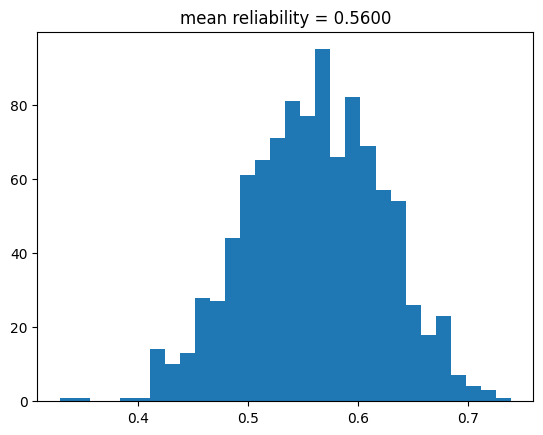

In [ ]:

# Plot histogram
plt.hist(sh_reliability_b, bins=30)

# Set title with mean reliability
plt.title(f"mean reliability = {np.mean(sh_reliability_b):.4f}")

plt.show()

# Shows low relaibility since it was measured with Device C which had the worst noise

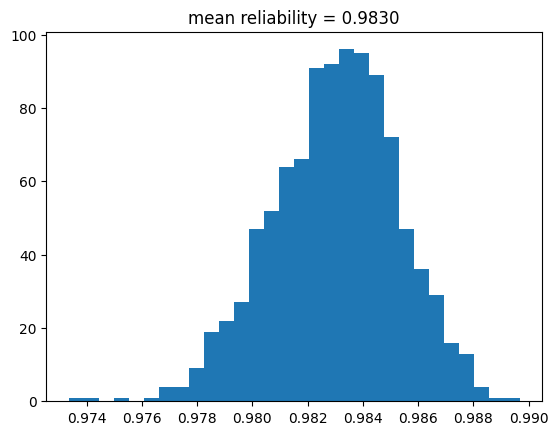

In [ ]:
# Plot histogram
plt.hist(sh_reliability_c, bins=30)

# Set title with mean reliability
plt.title(f"mean reliability = {np.mean(sh_reliability_c):.4f}")

plt.show()

# Shows high relaibility since it was measured with Device A which had the least noise

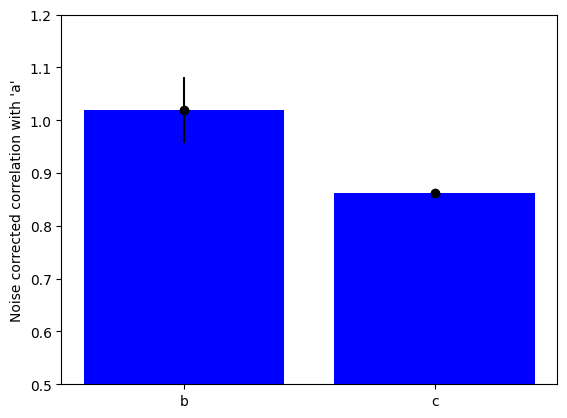

In [ ]:
# Now if we use the reliability measures to correct for the correlations, we can retrieve the true relations

# Correct the correlations
b_corr = np.corrcoef(a.squeeze(), avg_b_noisy)[0, 1] / np.sqrt(np.mean(sh_reliability_b))
c_corr = np.corrcoef(a.squeeze(), avg_c_noisy)[0, 1] / np.sqrt(np.mean(sh_reliability_c))

# Plot bar chart
means = [b_corr, c_corr]
std_devs = [np.std(sh_reliability_b), np.std(sh_reliability_c)]
positions = [1, 2]
plt.bar(positions, means, color='blue')

# Overlay error bars
plt.errorbar(positions, means, yerr=std_devs, fmt='ko', capsize=0)

# Label y-axis and set x-tick labels
plt.ylabel('Noise corrected correlation with \'a\'')
plt.xticks(positions, ['b', 'c'])
plt.ylim(0.5,1.2)
plt.show()

In [ ]:
# To make experiments more reliable, we can record more and more repetitions
# Let's vary the number of trials recorded and ask how does the measured reliability vary

nrTrials = [10, 20, 30, 40, 50, 60, 70, 80]
nrBS = 100

sh_reliability_b = np.empty((nrBS, len(nrTrials)))
sh_reliability_b[:] = np.nan

for j, trials in enumerate(nrTrials):

    # Create noisy 'b' for current number of trials
    b_noisy = np.empty((100, trials))
    b_noisy[:] = np.nan

    for i in range(trials):
        b_noisy[:, i] = b.squeeze() + 1.2 * np.random.randn(100)

    # Estimate split-half reliability
    for i in range(nrBS):
        l1 = np.random.choice(trials, int(trials / 2), replace=False)
        l2 = np.setdiff1d(np.arange(trials), l1)

        b_sh1 = np.mean(b_noisy[:, l1], axis=1)
        b_sh2 = np.mean(b_noisy[:, l2], axis=1)

        r_b = np.corrcoef(b_sh1, b_sh2)[0, 1]
        sh_reliability_b[i, j] = 2 * r_b / (1 + r_b) # Spearman Brown correction to correct for splits


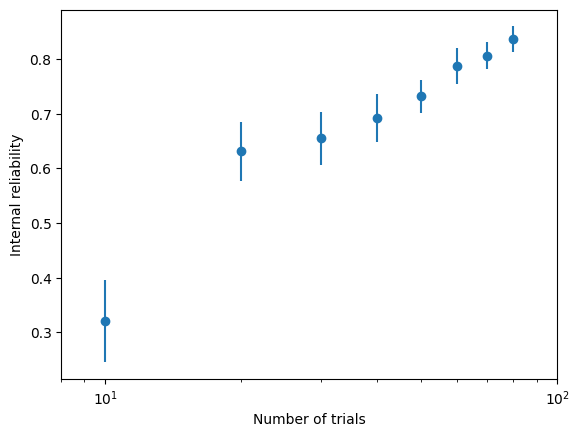

In [ ]:

# Plot reliability vs. number of trials recorded...

plt.errorbar(nrTrials, np.mean(sh_reliability_b, axis=0), np.std(sh_reliability_b, axis=0),
             marker='o', linestyle='', capsize=0)

# Set x-axis limits

plt.xlabel('Number of trials')
plt.ylabel('Internal reliability')

ax = plt.gca()  # Get the current axes
ax.set_xscale('log')
plt.xlim([8, 100])
plt.show()